## Desafio de previsão de vendas de uma loja utilizando os conhecimentos do módulo.



Setup

In [31]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


dados_vendas = {
  'mes': [
    'Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',  'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'
  ],
  'vendas': [
    2000, 2200, 2300, 2500, 2600, 2700,
    2800, 2900, 3000, 3100, 3200, 3300
  ]
}

Tratar os dados

In [9]:
df = pd.DataFrame(dados_vendas)
df.head()

,mes,vendas
0,Janeiro,2000
1,Fevereiro,2200
2,Março,2300
3,Abril,2500
4,Maio,2600


Formatar (se necessário)

In [19]:
df['mes_num'] = range(1, 13)
# df.head(12)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   mes      12 non-null     str  
 1   vendas   12 non-null     int64
 2   mes_num  12 non-null     int64
dtypes: int64(2), str(1)
memory usage: 420.0 bytes


Treinar o modelo

In [42]:
X_treino = df[['mes_num']][df['mes_num'] < 12]
y_treino = df[['vendas']][df['mes_num'] < 12]

X_teste = df[['mes_num']][df['mes_num'] == 12]
y_teste = df[['vendas']][df['mes_num'] == 12]

modelo = LinearRegression()
modelo.fit(X_treino, y_treino) 



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Prever a venda de dezembro

In [44]:
modelo.predict(X_teste)

array([[3356.36363636]])

Montar um histograma dos dados

(array([2., 2., 2., 3., 3.]),
 array([2000., 2260., 2520., 2780., 3040., 3300.]),
 <BarContainer object of 5 artists>)

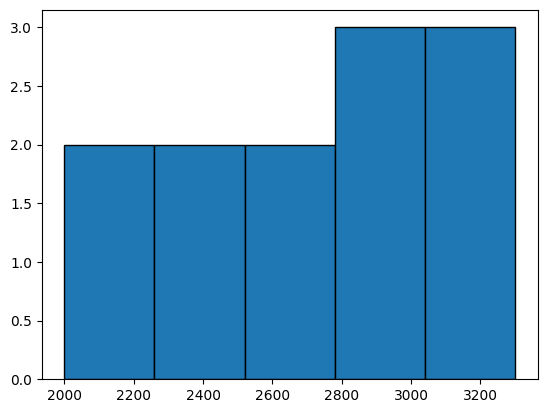

In [34]:
plt.hist(df['vendas'], bins=5, edgecolor='black')

Montar um plot de scatter 

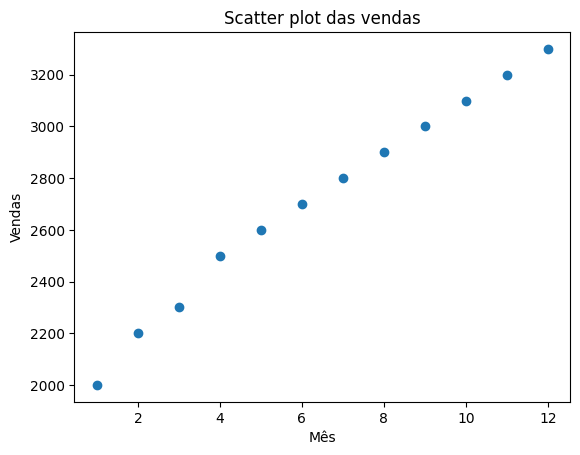

In [40]:
plt.scatter(df['mes_num'], df['vendas'])
plt.title("Scatter plot das vendas")
plt.xlabel("Mês")
plt.ylabel("Vendas")
plt.show()